# Hotel Booking Cancellation Analysis

## 1. Project Objective
This project analyses hotel booking data to identify the key factors associated with booking cancellations. The goal is to understand cancellation patterns and build a basic machine learning model that can predict whether a booking is likely to be cancelled.

This project connects to front office and hospitality operations, where cancellations, booking behaviour, and occupancy planning are important business areas.

## 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully")

Libraries imported successfully


## 3. Load Dataset

In [3]:
df = pd.read_csv('hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.shape

(119390, 32)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [7]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values.head(20)

company                           112593
agent                              16340
country                              488
children                               4
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
hotel                                  0
previous_cancellations                 0
days_in_waiting_list                   0
customer_type                          0
adr                                    0
required_car_parking_spaces            0
total_of_special_requests              0
reservation_status                     0
previous_bookings_not_canceled         0
is_repeated_guest                      0
is_canceled                            0
distribution_channel                   0
dtype: int64

In [8]:
missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_percentage.head(20)

company                           94.306893
agent                             13.686238
country                            0.408744
children                           0.003350
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                    0.000000
deposit_type                       0.000000
hotel                              0.000000
previous_cancellations             0.000000
days_in_waiting_list               0.000000
customer_type                      0.000000
adr                                0.000000
required_car_parking_spaces        0.000000
total_of_special_requests          0.000000
reservation_status                 0.000000
previous_bookings_not_canceled     0.000000
is_repeated_guest                  0.000000
is_canceled                        0.000000
distribution_channel               0.000000
dtype: float64

In [9]:
duplicate_count = df.duplicated().sum()
duplicate_count

31994

In [10]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [11]:
hotel_df = df.copy()

hotel_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 4. Data Cleaning

In [12]:
hotel_df["children"] = hotel_df["children"].fillna(0)
hotel_df["country"] = hotel_df["country"].fillna("Unknown")
hotel_df["agent"] = hotel_df["agent"].fillna(0)
# Drop company column because it has too many missing values
hotel_df = hotel_df.drop(columns=["company"])
hotel_df.isnull().sum().sort_values(ascending=False).head(20)

hotel                             0
is_repeated_guest                 0
reservation_status                0
total_of_special_requests         0
required_car_parking_spaces       0
adr                               0
customer_type                     0
days_in_waiting_list              0
agent                             0
deposit_type                      0
booking_changes                   0
assigned_room_type                0
reserved_room_type                0
previous_bookings_not_canceled    0
previous_cancellations            0
distribution_channel              0
is_canceled                       0
market_segment                    0
country                           0
meal                              0
dtype: int64

### The `company` column was dropped because it contained a very high number of missing values and was not essential for the cancellation analysis. Missing values in `children`, `country`, and `agent` were handled using reasonable replacements based on the meaning of each field.

### Removed the duplicate rows to reduce bias

In [13]:
hotel_df = hotel_df.drop_duplicates()

hotel_df.shape

(87389, 31)

### Removing invalid guest records

In [14]:
hotel_df["total_guests"] = hotel_df["adults"] + hotel_df["children"] + hotel_df["babies"]

In [15]:
hotel_df[hotel_df["total_guests"] == 0].shape

(166, 32)

In [16]:
hotel_df = hotel_df[hotel_df["total_guests"] > 0]

hotel_df.shape

(87223, 32)

## 5. Feature Engineering

#### Total nights
This helps us analyse whether longer stays cancel more often.

In [17]:
hotel_df["total_nights"] = hotel_df["stays_in_weekend_nights"] + hotel_df["stays_in_week_nights"]

#### Arrival date
The dataset stores year, month, and day separately. We combine them into one proper date column.

In [18]:
hotel_df["arrival_date"] = pd.to_datetime(
    hotel_df["arrival_date_year"].astype(str) + "-" +
    hotel_df["arrival_date_month"] + "-" +
    hotel_df["arrival_date_day_of_month"].astype(str),
    errors="coerce"
)

hotel_df[["arrival_date_year", "arrival_date_month", "arrival_date_day_of_month", "arrival_date"]].head()

,arrival_date_year,arrival_date_month,arrival_date_day_of_month,arrival_date
0,2015,July,1,2015-07-01
1,2015,July,1,2015-07-01
2,2015,July,1,2015-07-01
3,2015,July,1,2015-07-01
4,2015,July,1,2015-07-01


#### Has special request
Guests who make special requests may be more engaged and less likely to cancel.

In [19]:
hotel_df["has_special_request"] = np.where(
    hotel_df["total_of_special_requests"] > 0,
    1,
    0
)

#### Has previous cancellation
Past cancellation behaviour may indicate future cancellation risk.

In [20]:
hotel_df["has_previous_cancellation"] = np.where(
    hotel_df["previous_cancellations"] > 0,
    1,
    0
)

### 6. Exploratory Data Analysis
The dataset contains both cancelled and non-cancelled bookings. This allows us to analyse cancellation patterns and later build a classification model to predict cancellation risk.

### Check cancellation rate
0 = Not Cancelled
1 = Cancelled

In [21]:
cancellation_rate = hotel_df["is_canceled"].value_counts(normalize=True) * 100

cancellation_rate

hotel_df["is_canceled"].value_counts()

is_canceled
0    63214
1    24009
Name: count, dtype: int64

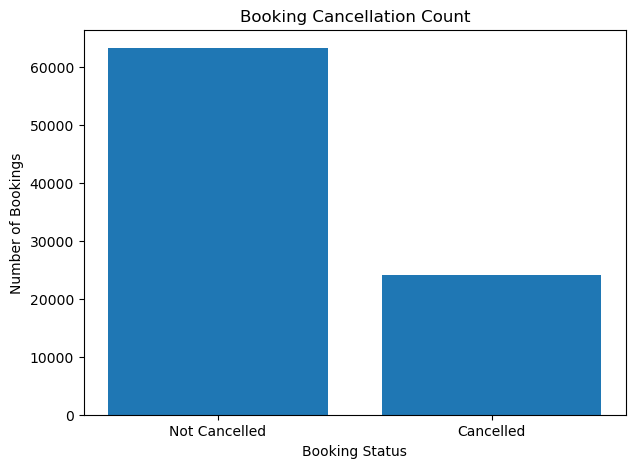

In [22]:
cancellation_counts = hotel_df["is_canceled"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(["Not Cancelled", "Cancelled"], cancellation_counts.values)
plt.title("Booking Cancellation Count")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")
plt.show()

### Cancellation rate by hotel type
This shows whether City Hotels or Resort Hotels have higher cancellation rates.

In [23]:
hotel_cancellation = (
    hotel_df.groupby("hotel")["is_canceled"]
    .mean()
    .sort_values(ascending=False) * 100
)

hotel_cancellation

hotel
City Hotel      30.10024
Resort Hotel    23.48679
Name: is_canceled, dtype: float64

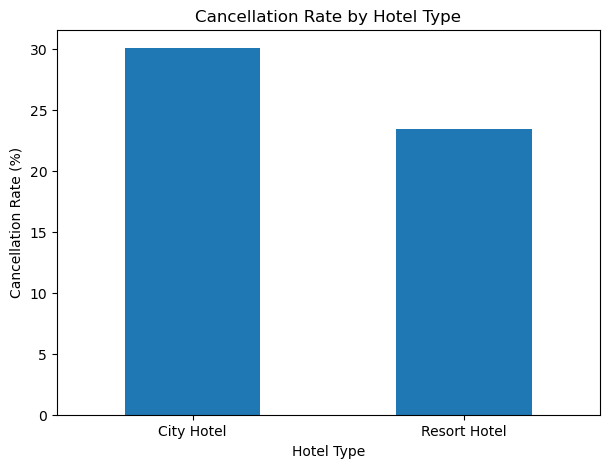

In [24]:
plt.figure(figsize=(7, 5))
hotel_cancellation.plot(kind="bar")
plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.show()

### Cancellation rate by customer type
Different customer types may behave differently. For example, transient customers may cancel more often.

In [25]:
customer_type_cancellation = (
    hotel_df.groupby("customer_type")["is_canceled"]
    .mean()
    .sort_values(ascending=False) * 100
)

customer_type_cancellation

customer_type
Transient          30.144173
Contract           16.331738
Transient-Party    15.253657
Group               9.796673
Name: is_canceled, dtype: float64

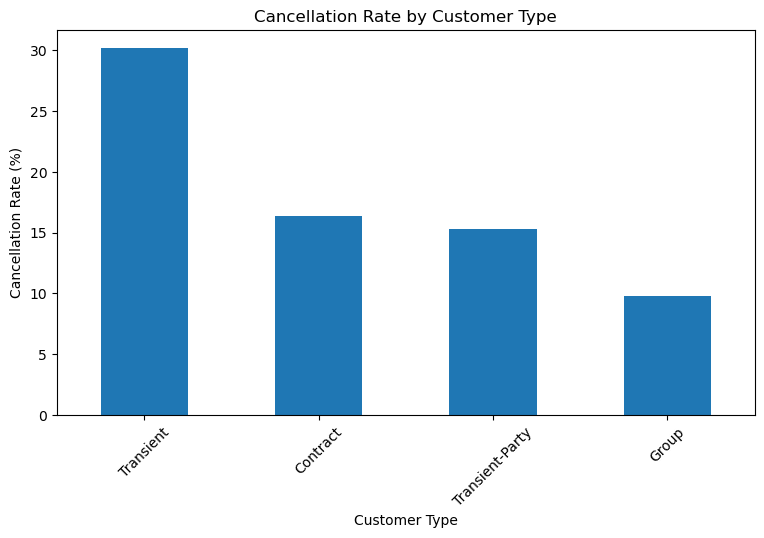

In [26]:
plt.figure(figsize=(9, 5))
customer_type_cancellation.plot(kind="bar")
plt.title("Cancellation Rate by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.show()

Transient customers showed the highest cancellation rate, while group bookings had the lowest. This suggests that individual short-term bookings may be less stable than group or contracted bookings.

### Cancellation rate by market segment
This helps identify whether online travel agencies, direct bookings, corporate bookings, etc., have different cancellation behaviour.

In [27]:
market_segment_cancellation = (
    hotel_df.groupby("market_segment")["is_canceled"]
    .mean()
    .sort_values(ascending=False) * 100
)

market_segment_cancellation

market_segment
Undefined        100.000000
Online TA         35.387003
Groups            27.062170
Aviation          19.911504
Offline TA/TO     14.846626
Direct            14.745331
Complementary     12.283237
Corporate         12.130601
Name: is_canceled, dtype: float64

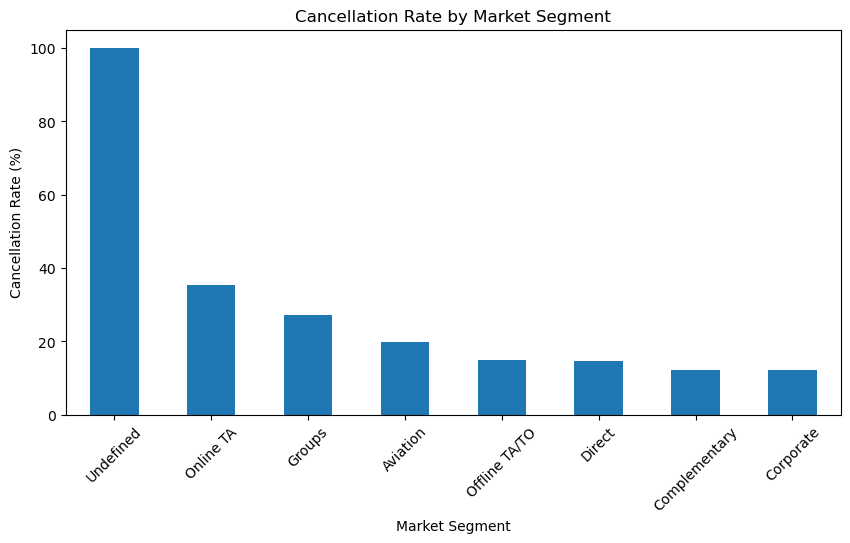

In [28]:
plt.figure(figsize=(10, 5))
market_segment_cancellation.plot(kind="bar")
plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.show()

The Undefined market segment showed a 100% cancellation rate, but this category contains only 2 rows, so it should not be overinterpreted.

### Cancellation rate by lead time group
Lead time is usually one of the strongest cancellation indicators. Bookings made far in advance may have higher cancellation risk.

In [29]:
hotel_df["lead_time_group"] = pd.cut(
    hotel_df["lead_time"],
    bins=[0, 7, 30, 90, 180, 365, hotel_df["lead_time"].max()],
    labels=["0-7 days", "8-30 days", "31-90 days", "91-180 days", "181-365 days", "365+ days"],
    include_lowest=True
)

In [30]:
lead_time_cancellation = (
    hotel_df.groupby("lead_time_group", observed=False)["is_canceled"]
    .mean() * 100
)

lead_time_cancellation

lead_time_group
0-7 days         8.418045
8-30 days       25.393616
31-90 days      32.042254
91-180 days     35.008780
181-365 days    39.685518
365+ days       40.780142
Name: is_canceled, dtype: float64

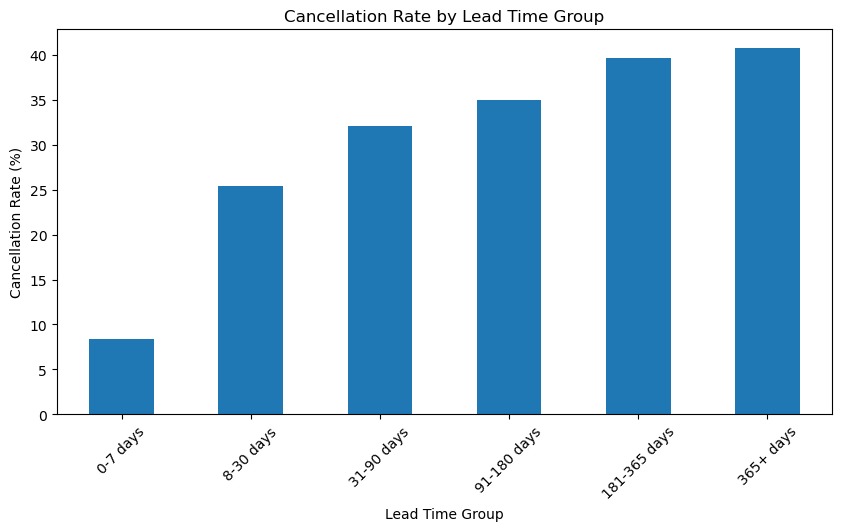

In [31]:
plt.figure(figsize=(10, 5))
lead_time_cancellation.plot(kind="bar")
plt.title("Cancellation Rate by Lead Time Group")
plt.xlabel("Lead Time Group")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.show()

Bookings made further in advance showed much higher cancellation rates, suggesting that long lead-time bookings carry greater uncertainty. Hotels can use lead time as an important risk indicator for occupancy planning.

### Cancellation rate by special requests
Guests who make special requests may be more committed to their booking.

In [32]:
special_request_cancellation = (
    hotel_df.groupby("has_special_request")["is_canceled"]
    .mean() * 100
)

special_request_cancellation.index = ["No Special Request", "Has Special Request"]

special_request_cancellation

No Special Request     33.256441
Has Special Request    21.750040
Name: is_canceled, dtype: float64

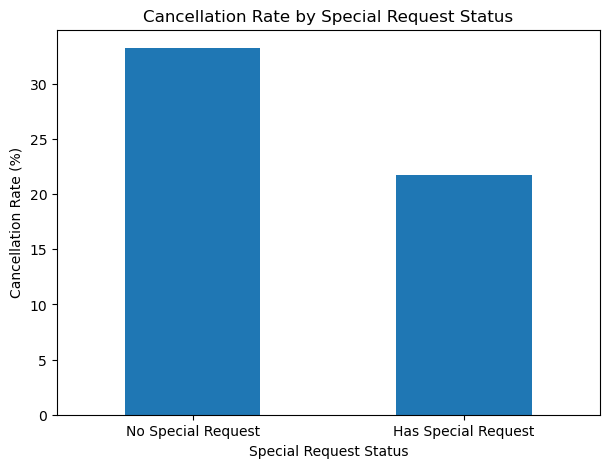

In [33]:
plt.figure(figsize=(7, 5))
special_request_cancellation.plot(kind="bar")
plt.title("Cancellation Rate by Special Request Status")
plt.xlabel("Special Request Status")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.show()

# 7. Advanced Feature Analysis

In this section, new business-focused features are created to better understand cancellation behaviour and prepare the dataset for machine learning.

### 1. Family booking flag
Why we do this: family bookings may behave differently from solo/couple bookings. Families might be less likely to cancel because they plan more carefully.

In [34]:
hotel_df["is_family_booking"] = np.where(
    (hotel_df["children"] > 0) | (hotel_df["babies"] > 0),
    1,
    0
)

hotel_df[["adults", "children", "babies", "is_family_booking"]].head(15)

,adults,children,babies,is_family_booking
0,2,0.0,0,0
1,2,0.0,0,0
2,1,0.0,0,0
3,1,0.0,0,0
4,2,0.0,0,0
6,2,0.0,0,0
7,2,0.0,0,0
8,2,0.0,0,0
9,2,0.0,0,0
10,2,0.0,0,0


### 2. Couple / solo / group booking type
Why this is useful: it gives a more understandable guest profile than just adults/children/babies separately.

In [35]:
def booking_party_type(row):
    if row["total_guests"] == 1:
        return "Solo"
    elif row["total_guests"] == 2:
        return "Couple"
    elif row["is_family_booking"] == 1:
        return "Family"
    else:
        return "Group"

hotel_df["booking_party_type"] = hotel_df.apply(booking_party_type, axis=1)

hotel_df["booking_party_type"].value_counts()

booking_party_type
Couple    57055
Solo      16067
Family     8624
Group      5477
Name: count, dtype: int64

### 3. Weekend Stay 
Why: weekend stays may have different cancellation patterns compared to weekday/business stays.

In [36]:
hotel_df["has_weekend_stay"] = np.where(
    hotel_df["stays_in_weekend_nights"] > 0,
    1,
    0
)

hotel_df[["stays_in_weekend_nights", "stays_in_week_nights", "has_weekend_stay"]].head()

,stays_in_weekend_nights,stays_in_week_nights,has_weekend_stay
0,0,0,0
1,0,0,0
2,0,1,0
3,0,1,0
4,0,2,0


### 4. Stay length groups
Why: instead of analysing every stay length separately, grouping makes it easier to interpret.

In [37]:
hotel_df["stay_length_group"] = pd.cut(
    hotel_df["total_nights"],
    bins=[0, 1, 3, 7, 14, hotel_df["total_nights"].max()],
    labels=["1 night", "2-3 nights", "4-7 nights", "8-14 nights", "15+ nights"],
    include_lowest=True
)

hotel_df["stay_length_group"].value_counts()

stay_length_group
2-3 nights     33561
4-7 nights     31077
1 night        17753
8-14 nights     4468
15+ nights       364
Name: count, dtype: int64

### 5. ADR price bands
ADR means Average Daily Rate, basically the average price per room night.
Why: this helps analyse whether expensive bookings cancel more or less often.

In [38]:
hotel_df["adr_group"] = pd.cut(
    hotel_df["adr"],
    bins=[0, 50, 100, 150, 250, hotel_df["adr"].max()],
    labels=["Low", "Medium", "High", "Premium", "Luxury"],
    include_lowest=True
)

hotel_df["adr_group"].value_counts()

adr_group
Medium     35781
High       26628
Premium    13890
Low         9704
Luxury      1219
Name: count, dtype: int64

In [39]:
hotel_df["adr"].describe()

count    87223.000000
mean       106.519872
std         54.890351
min         -6.380000
25%         72.250000
50%         98.200000
75%        134.100000
max       5400.000000
Name: adr, dtype: float64

### 6. Room Mismatch 
This is a strong feature.
Some customers receive a different room type than they reserved.
Why this matters: room assignment differences may be linked with booking changes, upgrades, operational issues, or customer satisfaction.

In [40]:
hotel_df["room_type_changed"] = np.where(
    hotel_df["reserved_room_type"] != hotel_df["assigned_room_type"],
    1,
    0
)

hotel_df[["reserved_room_type", "assigned_room_type", "room_type_changed"]].head()

,reserved_room_type,assigned_room_type,room_type_changed
0,C,C,0
1,C,C,0
2,A,C,1
3,A,A,0
4,A,A,0


### 7. Lead time risk group
Why: this is useful for business recommendations and ML interpretation.

In [41]:
def lead_time_risk(days):
    if days <= 7:
        return "Very Low Risk"
    elif days <= 30:
        return "Low Risk"
    elif days <= 90:
        return "Medium Risk"
    elif days <= 180:
        return "High Risk"
    else:
        return "Very High Risk"

hotel_df["lead_time_risk"] = hotel_df["lead_time"].apply(lead_time_risk)

hotel_df["lead_time_risk"].value_counts()

lead_time_risk
Medium Risk       22720
High Risk         18224
Very Low Risk     18199
Low Risk          16323
Very High Risk    11757
Name: count, dtype: int64

### 8. Previous booking history flag
Why: returning guests may have different cancellation behaviour from first-time guests.

In [42]:
hotel_df["has_previous_bookings"] = np.where(
    hotel_df["previous_bookings_not_canceled"] > 0,
    1,
    0
)

hotel_df[["previous_bookings_not_canceled", "has_previous_bookings"]].head()

,previous_bookings_not_canceled,has_previous_bookings
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


### 9. Booking change flag
Why: booking changes can indicate uncertainty, but they can also indicate engagement. We’ll analyse which direction it goes.

In [43]:
hotel_df["has_booking_changes"] = np.where(
    hotel_df["booking_changes"] > 0,
    1,
    0
)

hotel_df[["booking_changes", "has_booking_changes"]].head()

,booking_changes,has_booking_changes
0,3,1
1,4,1
2,0,0
3,0,0
4,0,0


### 10. Waiting list flag
Why: bookings involving waiting lists may show different cancellation patterns.

In [44]:
hotel_df["was_on_waiting_list"] = np.where(
    hotel_df["days_in_waiting_list"] > 0,
    1,
    0
)

hotel_df[["days_in_waiting_list", "was_on_waiting_list"]].head()

,days_in_waiting_list,was_on_waiting_list
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


## 7.5 Advanced Cancellation Analysis
This section analyses cancellation behaviour across engineered features such as guest type, stay length, ADR band, room changes, previous booking history, and lead time risk.

### 1. Cancellation by party type
Business question: are solo, couple, family, or group bookings more likely to cancel?

In [45]:
party_type_cancel = (
    hotel_df.groupby("booking_party_type")["is_canceled"]
    .mean()
    .sort_values(ascending=False) * 100
)

party_type_cancel

booking_party_type
Family    34.508349
Group     33.576776
Couple    28.218386
Solo      19.256862
Name: is_canceled, dtype: float64

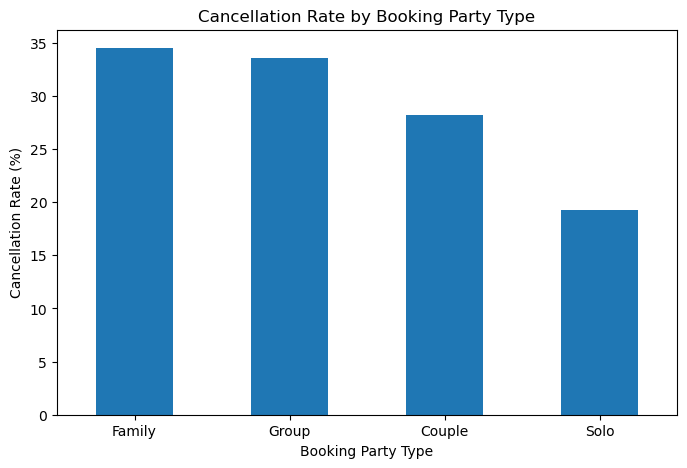

In [46]:
plt.figure(figsize=(8, 5))
party_type_cancel.plot(kind="bar")
plt.title("Cancellation Rate by Booking Party Type")
plt.xlabel("Booking Party Type")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.show()

Family and group bookings showed higher cancellation rates than solo bookings. Larger booking parties may involve more planning uncertainty, which can increase the likelihood of cancellation.

### 2. Cancellation by stay length group
Business question: do longer stays have higher cancellation risk?

In [47]:
stay_length_cancel = (
    hotel_df.groupby("stay_length_group", observed=False)["is_canceled"]
    .mean() * 100
)

stay_length_cancel

stay_length_group
1 night        17.934997
2-3 nights     28.446709
4-7 nights     30.961805
8-14 nights    32.811101
15+ nights     52.197802
Name: is_canceled, dtype: float64

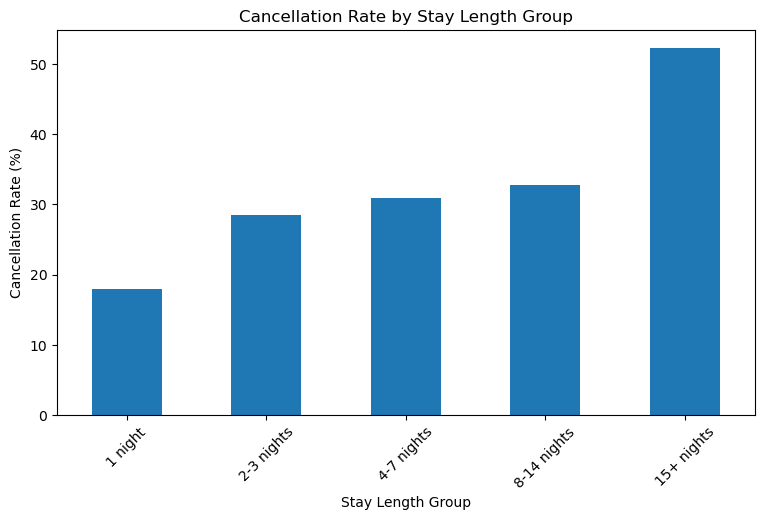

In [48]:
plt.figure(figsize=(9, 5))
stay_length_cancel.plot(kind="bar")
plt.title("Cancellation Rate by Stay Length Group")
plt.xlabel("Stay Length Group")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.show()

Longer stays showed higher cancellation rates, indicating that extended bookings may require closer monitoring or stronger confirmation policies.

### 3. Cancellation by ADR group
Business question: do higher-priced bookings cancel more often?

In [49]:
adr_cancel = (
    hotel_df.groupby("adr_group", observed=False)["is_canceled"]
    .mean() * 100
)

adr_cancel

adr_group
Low        14.993817
Medium     24.476678
High       31.894998
Premium    34.917207
Luxury     37.161608
Name: is_canceled, dtype: float64

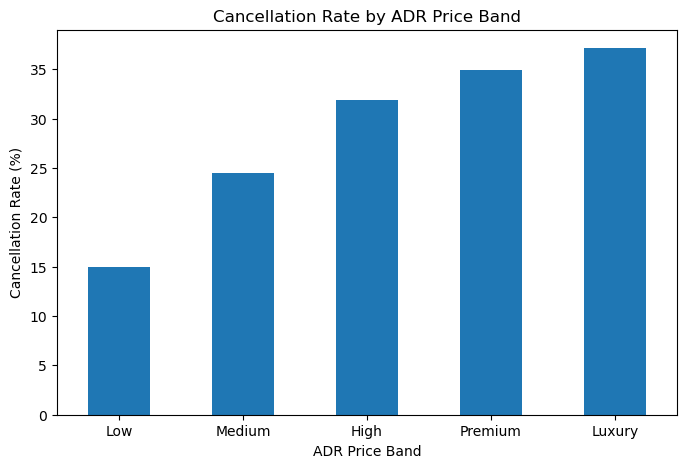

In [50]:
plt.figure(figsize=(8, 5))
adr_cancel.plot(kind="bar")
plt.title("Cancellation Rate by ADR Price Band")
plt.xlabel("ADR Price Band")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.show()

Cancellation rates increased across higher ADR price bands, suggesting that more expensive bookings may carry higher cancellation risk. This could be due to customers comparing prices, changing plans, or being more sensitive to high booking costs.

### 4. Cancellation by room type change

In [51]:
room_change_cancel = (
    hotel_df.groupby("room_type_changed")["is_canceled"]
    .mean() * 100
)

room_change_cancel.index = ["Same Room Type", "Room Type Changed"]

room_change_cancel

Same Room Type       31.511665
Room Type Changed     4.743205
Name: is_canceled, dtype: float64

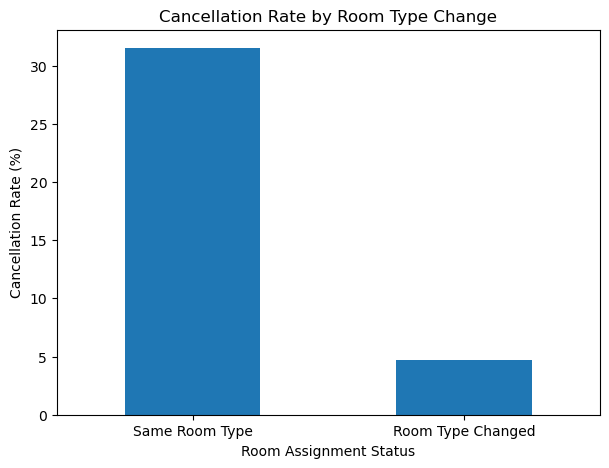

In [52]:
plt.figure(figsize=(7, 5))
room_change_cancel.plot(kind="bar")
plt.title("Cancellation Rate by Room Type Change")
plt.xlabel("Room Assignment Status")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.show()

Bookings where the assigned room type differed from the reserved room type showed lower cancellation rates. This may indicate that room assignment changes often occur after the booking has progressed further operationally, or that upgraded/adjusted bookings are less likely to be cancelled. This feature should be interpreted carefully because the timing of room assignment may affect the result.

### 5. Cancellation by previous booking history
Business question: are returning guests more reliable?

In [53]:
previous_booking_cancel = (
    hotel_df.groupby("has_previous_bookings")["is_canceled"]
    .mean() * 100
)

previous_booking_cancel.index = ["No Previous Bookings", "Has Previous Bookings"]

previous_booking_cancel

No Previous Bookings     28.478222
Has Previous Bookings     5.002826
Name: is_canceled, dtype: float64

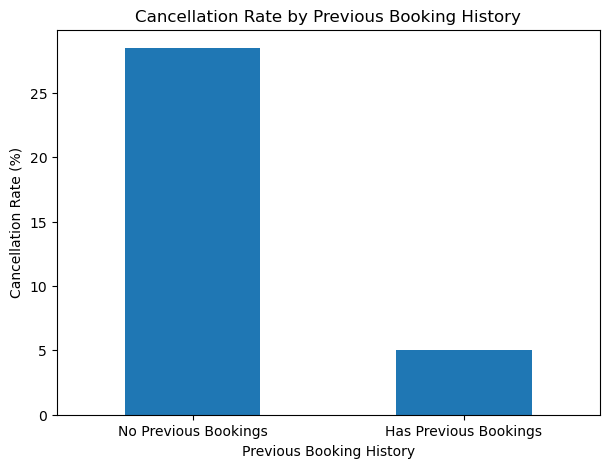

In [54]:
plt.figure(figsize=(7, 5))
previous_booking_cancel.plot(kind="bar")
plt.title("Cancellation Rate by Previous Booking History")
plt.xlabel("Previous Booking History")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.show()

Guests with previous booking history had a much lower cancellation rate compared to first-time guests. This suggests that returning customers may be more reliable and could be valuable for loyalty or retention strategies.

### 6. Cancellation by booking changes
Business question: do booking changes indicate higher or lower cancellation risk?

In [55]:
booking_changes_cancel = (
    hotel_df.groupby("has_booking_changes")["is_canceled"]
    .mean() * 100
)

booking_changes_cancel.index = ["No Booking Changes", "Has Booking Changes"]

booking_changes_cancel

No Booking Changes     30.181467
Has Booking Changes    15.526732
Name: is_canceled, dtype: float64

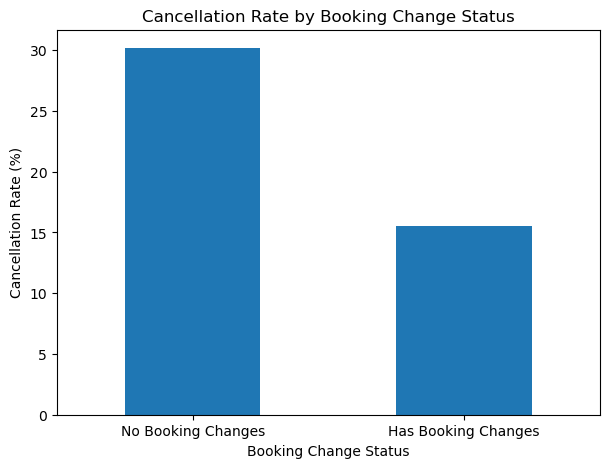

In [56]:
plt.figure(figsize=(7, 5))
booking_changes_cancel.plot(kind="bar")
plt.title("Cancellation Rate by Booking Change Status")
plt.xlabel("Booking Change Status")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.show()

Bookings with changes had a lower cancellation rate than bookings with no changes. This may suggest that customers who modify their booking are still engaged with the hotel rather than abandoning the reservation entirely.

### 8. Cancellation by deposit type

In [57]:
deposit_cancel = (
    hotel_df.groupby("deposit_type")["is_canceled"]
    .mean()
    .sort_values(ascending=False) * 100
)

deposit_cancel

deposit_type
Non Refund    94.701349
No Deposit    26.719952
Refundable    24.299065
Name: is_canceled, dtype: float64

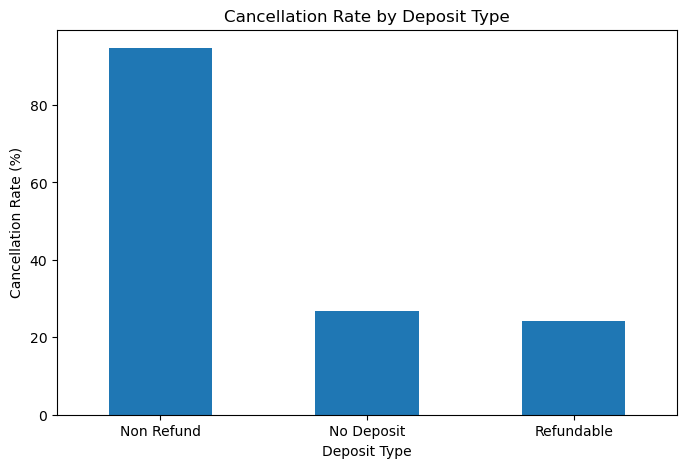

In [58]:
plt.figure(figsize=(8, 5))
deposit_cancel.plot(kind="bar")
plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.show()

### 9. Monthly cancellation trend
Business question: are cancellations seasonal?

In [59]:
monthly_cancel = (
    hotel_df.groupby("arrival_date_month")["is_canceled"]
    .mean() * 100
)

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_cancel = monthly_cancel.reindex(month_order)

monthly_cancel

arrival_date_month
January      22.134472
February     23.216047
March        24.422486
April        30.455696
May          29.270047
June         30.337803
July         31.826329
August       32.218466
September    24.562191
October      23.724895
November     21.162744
December     26.941890
Name: is_canceled, dtype: float64

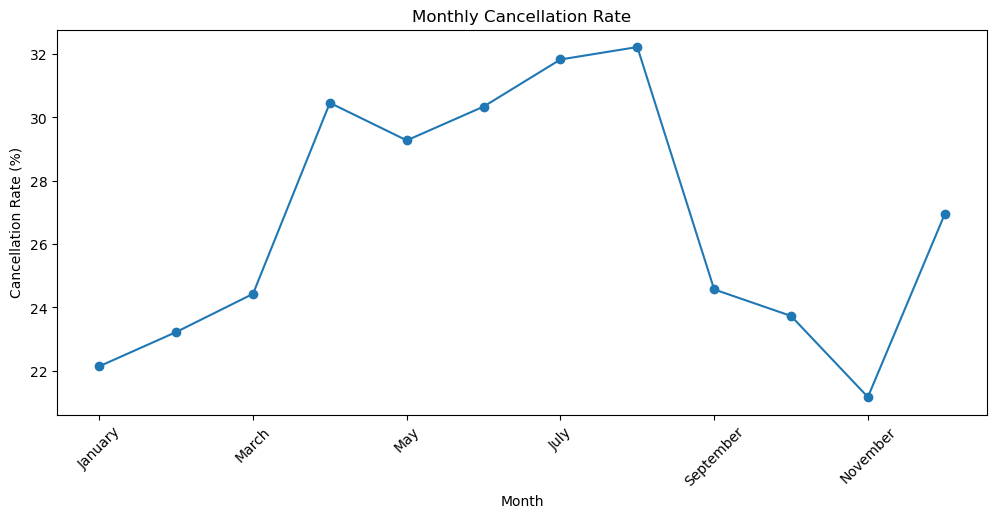

In [60]:
plt.figure(figsize=(12, 5))
monthly_cancel.plot(kind="line", marker="o")
plt.title("Monthly Cancellation Rate")
plt.xlabel("Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.show()

Cancellation rates varied by arrival month, with higher cancellation rates during mid-year months. This suggests seasonality plays a role in cancellation behaviour and should be considered in forecasting.

### 10. Correlation heatmap-style table

In [61]:
numeric_features = [
    "is_canceled",
    "lead_time",
    "adr",
    "total_guests",
    "total_nights",
    "previous_cancellations",
    "booking_changes",
    "days_in_waiting_list",
    "total_of_special_requests",
    "room_type_changed",
    "has_special_request",
    "has_previous_cancellation",
    "has_previous_bookings"
]

correlation_with_cancel = (
    hotel_df[numeric_features]
    .corr()["is_canceled"]
    .sort_values(ascending=False)
)

correlation_with_cancel

is_canceled                  1.000000
lead_time                    0.184482
adr                          0.127221
has_previous_cancellation    0.127015
total_guests                 0.098946
total_nights                 0.085388
previous_cancellations       0.051497
days_in_waiting_list         0.004707
booking_changes             -0.093257
has_previous_bookings       -0.103686
total_of_special_requests   -0.120816
has_special_request         -0.128808
room_type_changed           -0.213349
Name: is_canceled, dtype: float64

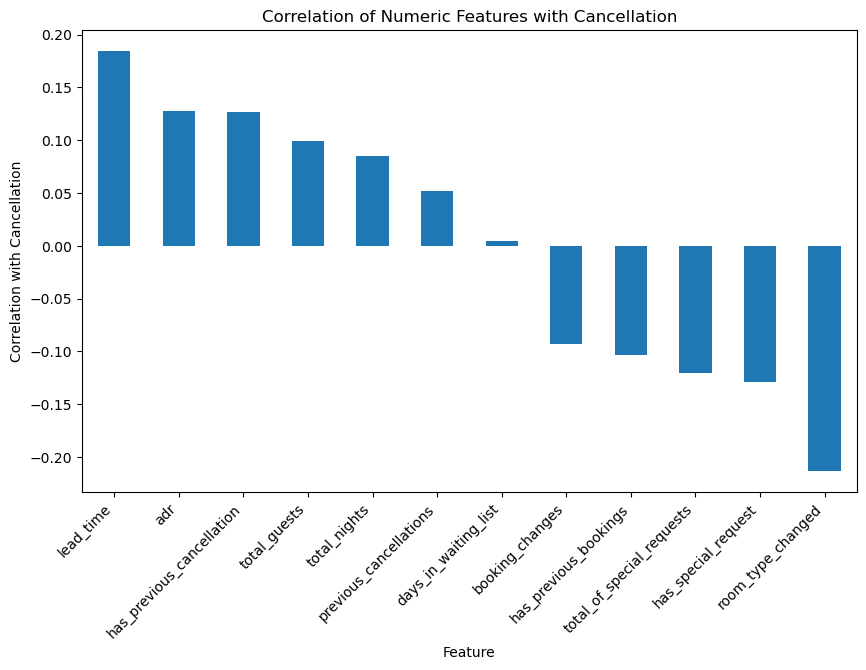

In [62]:
plt.figure(figsize=(10, 6))
correlation_with_cancel.drop("is_canceled").plot(kind="bar")
plt.title("Correlation of Numeric Features with Cancellation")
plt.xlabel("Feature")
plt.ylabel("Correlation with Cancellation")
plt.xticks(rotation=45, ha="right")
plt.show()

### Correlation Analysis Insight

Lead time showed the strongest positive correlation with cancellation, suggesting that bookings made further in advance carry higher cancellation risk. Previous cancellation history and ADR also showed positive relationships with cancellation.

Special requests, room type changes, and booking changes showed negative correlations with cancellation. This suggests that guests who are more engaged with their booking, such as those making requests or changes, may be less likely to cancel.

These correlations are not proof of causation, but they help identify useful features for cancellation prediction modelling.

## Some of the Key Findings from Exploratory Analysis

- Bookings with longer lead times had significantly higher cancellation rates, making lead time one of the strongest indicators of cancellation risk.
- Longer stays, especially bookings of 15+ nights, showed higher cancellation rates.
- Transient customers had the highest cancellation rate among customer types.
- Cancellation rates varied by month, indicating seasonal cancellation patterns.
- Guests with special requests appeared less likely to cancel, suggesting stronger booking commitment.
- Deposit type and market segment showed major differences in cancellation behaviour, but some categories should be interpreted carefully due to possible small sample sizes.
- Higher ADR price bands showed higher cancellation rates, suggesting that expensive bookings may carry greater cancellation risk.
- Returning guests had a much lower cancellation rate than first-time guests, indicating stronger booking reliability.
- Family and group bookings showed higher cancellation rates than solo bookings, possibly due to greater planning complexity.
- Bookings with special requests, booking changes, or room type changes showed lower cancellation rates, which may indicate stronger guest engagement.


# --Machine Learning Section--

# Machine Learning Model

The goal of this section is to build classification models that predict whether a hotel booking is likely to be cancelled.

The target variable is `is_canceled`:
- 0 = Not cancelled
- 1 = Cancelled

Two models are compared:
1. Logistic Regression
2. Random Forest Classifier

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("Machine learning libraries imported successfully")

Machine learning libraries imported successfully


In [64]:
features = [
    "hotel",
    "lead_time",
    "arrival_date_month",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "total_nights",
    "adults",
    "children",
    "babies",
    "total_guests",
    "meal",
    "market_segment",
    "distribution_channel",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "reserved_room_type",
    "assigned_room_type",
    "room_type_changed",
    "booking_changes",
    "deposit_type",
    "agent",
    "customer_type",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "has_special_request",
    "has_previous_cancellation",
    "has_previous_bookings",
    "has_booking_changes",
    "was_on_waiting_list",
    "lead_time_group",
    "lead_time_risk",
    "stay_length_group",
    "adr_group",
    "booking_party_type",
    "is_family_booking",
    "has_weekend_stay"
]

target = "is_canceled"

X = hotel_df[features]
y = hotel_df[target]

X.head()

,hotel,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,total_nights,adults,children,babies,total_guests,meal,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,room_type_changed,booking_changes,deposit_type,agent,customer_type,adr,required_car_parking_spaces,total_of_special_requests,has_special_request,has_previous_cancellation,has_previous_bookings,has_booking_changes,was_on_waiting_list,lead_time_group,lead_time_risk,stay_length_group,adr_group,booking_party_type,is_family_booking,has_weekend_stay
0,Resort Hotel,342,July,0,0,0,2,0.0,0,2.0,BB,Direct,Direct,0,0,0,C,C,0,3,No Deposit,0.0,Transient,0.0,0,0,0,0,0,1,0,181-365 days,Very High Risk,1 night,Low,Couple,0,0
1,Resort Hotel,737,July,0,0,0,2,0.0,0,2.0,BB,Direct,Direct,0,0,0,C,C,0,4,No Deposit,0.0,Transient,0.0,0,0,0,0,0,1,0,365+ days,Very High Risk,1 night,Low,Couple,0,0
2,Resort Hotel,7,July,0,1,1,1,0.0,0,1.0,BB,Direct,Direct,0,0,0,A,C,1,0,No Deposit,0.0,Transient,75.0,0,0,0,0,0,0,0,0-7 days,Very Low Risk,1 night,Medium,Solo,0,0
3,Resort Hotel,13,July,0,1,1,1,0.0,0,1.0,BB,Corporate,Corporate,0,0,0,A,A,0,0,No Deposit,304.0,Transient,75.0,0,0,0,0,0,0,0,8-30 days,Low Risk,1 night,Medium,Solo,0,0
4,Resort Hotel,14,July,0,2,2,2,0.0,0,2.0,BB,Online TA,TA/TO,0,0,0,A,A,0,0,No Deposit,240.0,Transient,98.0,0,1,1,0,0,0,0,8-30 days,Low Risk,2-3 nights,Medium,Couple,0,0


### Checking feature data types

In [65]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87223 entries, 0 to 119389
Data columns (total 38 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   hotel                           87223 non-null  object  
 1   lead_time                       87223 non-null  int64   
 2   arrival_date_month              87223 non-null  object  
 3   stays_in_weekend_nights         87223 non-null  int64   
 4   stays_in_week_nights            87223 non-null  int64   
 5   total_nights                    87223 non-null  int64   
 6   adults                          87223 non-null  int64   
 7   children                        87223 non-null  float64 
 8   babies                          87223 non-null  int64   
 9   total_guests                    87223 non-null  float64 
 10  meal                            87223 non-null  object  
 11  market_segment                  87223 non-null  object  
 12  distribution_channel  

### Separating numerical and categorical columns
Machine learning models need numbers. Categorical values like hotel, market_segment, and customer_type must be converted into numeric form.

In [66]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'total_nights', 'adults', 'children', 'babies', 'total_guests', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical features:
['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'lead_time_group', 'lead_time_risk', 'stay_length_group', 'adr_group', 'booking_party_type']


### Create preprocessing pipeline
Why we do this:

StandardScaler scales numeric features like lead_time, adr, and total_nights.

OneHotEncoder converts text categories into numeric columns.

ColumnTransformer applies the right transformation to the right column type.

In [67]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created")

Preprocessing pipeline created


### Train-test split

Why:
We train the model on 80% of the data and test it on 20% unseen data.

stratify=y keeps the cancellation/non-cancellation ratio similar in both train and test sets.

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 69778
Testing rows: 17445


### Build Logistic Regression model

In [69]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully")

Logistic Regression model trained successfully


### Evaluate Logistic Regression

In [70]:
y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)
logistic_roc_auc = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy:", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall:", round(logistic_recall, 4))
print("F1 Score:", round(logistic_f1, 4))
print("ROC-AUC:", round(logistic_roc_auc, 4))

Logistic Regression Performance
--------------------------------
Accuracy: 0.801
Precision: 0.6945
Recall: 0.4948
F1 Score: 0.5779
ROC-AUC: 0.8263


In [71]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87     12643
           1       0.69      0.49      0.58      4802

    accuracy                           0.80     17445
   macro avg       0.76      0.71      0.72     17445
weighted avg       0.79      0.80      0.79     17445



### Build Random Forest model

In [72]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully")

Random Forest model trained successfully


### Evaluate Random Forest

In [73]:
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy:", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall:", round(rf_recall, 4))
print("F1 Score:", round(rf_f1, 4))
print("ROC-AUC:", round(rf_roc_auc, 4))

Random Forest Performance
-------------------------
Accuracy: 0.8123
Precision: 0.7021
Recall: 0.5527
F1 Score: 0.6185
ROC-AUC: 0.8509


In [74]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.91      0.88     12643
           1       0.70      0.55      0.62      4802

    accuracy                           0.81     17445
   macro avg       0.77      0.73      0.75     17445
weighted avg       0.80      0.81      0.80     17445



### Compare model performance

In [75]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [logistic_accuracy, rf_accuracy],
    "Precision": [logistic_precision, rf_precision],
    "Recall": [logistic_recall, rf_recall],
    "F1 Score": [logistic_f1, rf_f1],
    "ROC-AUC": [logistic_roc_auc, rf_roc_auc]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.801032,0.694534,0.494794,0.577891,0.826288
1,Random Forest,0.812324,0.702116,0.552686,0.618504,0.850887


<Figure size 1000x600 with 0 Axes>

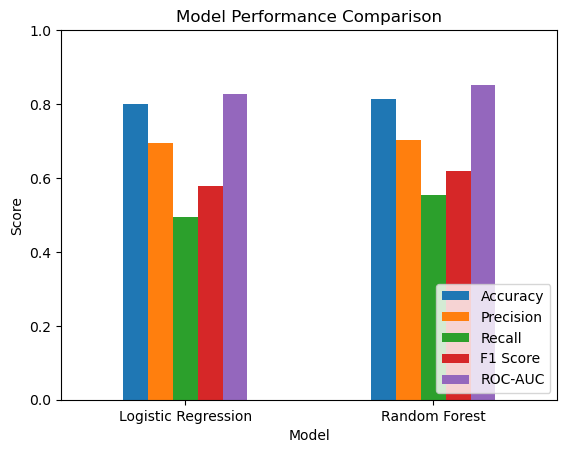

In [76]:
model_comparison_plot = model_comparison.set_index("Model")

plt.figure(figsize=(10, 6))
model_comparison_plot[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

The Random Forest model performed best overall, achieving an accuracy of 81.23% and ROC-AUC of 85.09%. The model improved recall compared to Logistic Regression, meaning it identified a larger share of actual cancellations. For hotel operations, this is useful because identifying potential cancellations early can support occupancy planning and follow-up actions.

### Confusion matrix for Random Forest

In [77]:
rf_cm = confusion_matrix(y_test, y_pred_rf)

rf_cm

array([[11517,  1126],
       [ 2148,  2654]], dtype=int64)

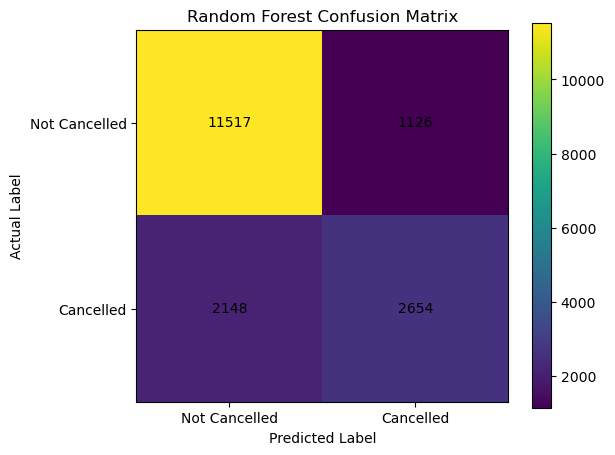

In [78]:
plt.figure(figsize=(6, 5))
plt.imshow(rf_cm)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["Not Cancelled", "Cancelled"])
plt.yticks([0, 1], ["Not Cancelled", "Cancelled"])

for i in range(rf_cm.shape[0]):
    for j in range(rf_cm.shape[1]):
        plt.text(j, i, rf_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

The confusion matrix shows that the Random Forest model correctly predicted 11,517 non-cancelled bookings and 2,654 cancelled bookings. However, it missed 2,148 actual cancellations. This means the model is useful for cancellation risk screening, but further tuning could improve its ability to capture more high-risk bookings.

### Random Forest feature importance

In [79]:
rf_classifier = random_forest_model.named_steps["classifier"]
preprocessor_fitted = random_forest_model.named_steps["preprocessor"]

encoded_feature_names = preprocessor_fitted.get_feature_names_out()
feature_importances = rf_classifier.feature_importances_

importance_df = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

importance_df.head(20)

,Feature,Importance
0,num__lead_time,0.134394
13,num__adr,0.104224
15,num__total_of_special_requests,0.057761
12,num__agent,0.049947
14,num__required_car_parking_spaces,0.041936
2,num__stays_in_week_nights,0.039091
3,num__total_nights,0.037286
1,num__stays_in_weekend_nights,0.028140
11,num__booking_changes,0.021872
41,cat__market_segment_Online TA,0.021749


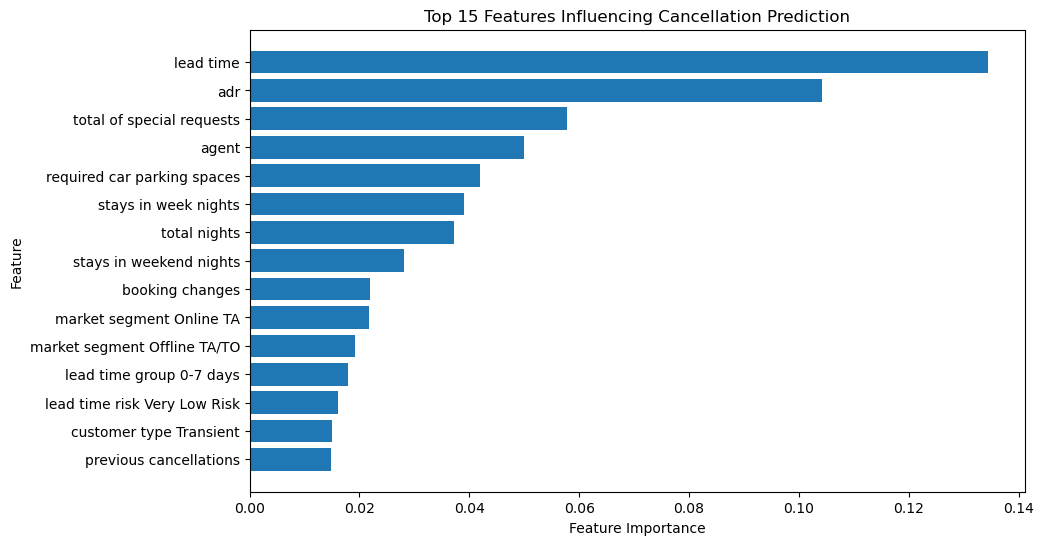

In [80]:
importance_df["Feature Clean"] = (
    importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("_", " ", regex=False)
)

top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature Clean"], top_features["Importance"])
plt.title("Top 15 Features Influencing Cancellation Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

Feature importance analysis showed that lead time was the strongest predictor of cancellation, followed by ADR, special requests, agent, parking space requirements, stay length, booking changes, market segment, customer type, and previous cancellations.

These results align with the exploratory analysis, where longer lead times, higher ADR price bands, customer type, and previous cancellation behaviour were associated with higher cancellation risk. Special requests and booking changes also appeared important, suggesting that guest engagement may influence cancellation behaviour.

# Advanced Model Evaluation

### 1. ROC Curve


The ROC curve evaluates how well the model separates cancelled and non-cancelled bookings across different classification thresholds.

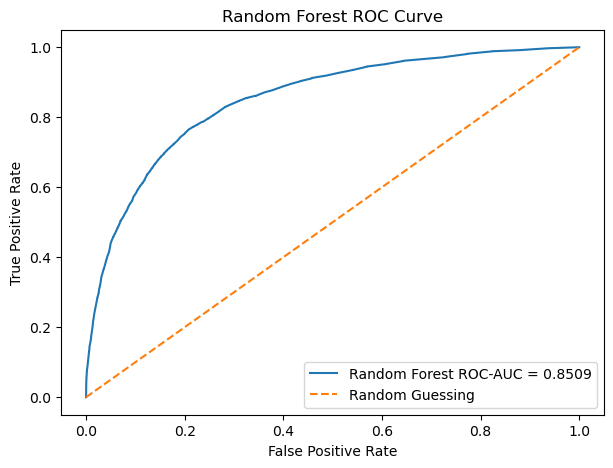

In [81]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Random Forest ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guessing")
plt.title("Random Forest ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### 2. Add Precision-Recall Curve

The Precision-Recall curve helps evaluate how well the model identifies cancelled bookings, especially when the business goal is to detect high-risk bookings.

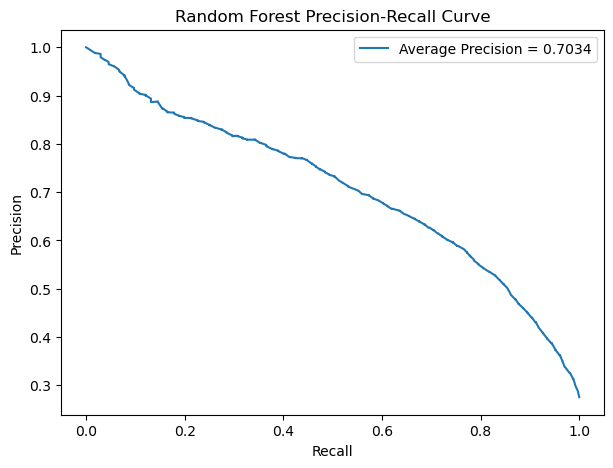

In [82]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob_rf)
avg_precision = average_precision_score(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"Average Precision = {avg_precision:.4f}")
plt.title("Random Forest Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

### 3. Threshold tuning

The default classification threshold is 0.50. However, for hotel cancellation risk prediction, it may be useful to lower the threshold to identify more high-risk bookings. This can improve recall, meaning the model catches more actual cancellations, although it may also increase false positives.

In [83]:
threshold_results = []

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    y_pred_threshold = (y_prob_rf >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1 Score": f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.30,0.784637,0.583029,0.764057,0.661379
1,0.35,0.798051,0.615080,0.711787,0.659909
2,0.40,0.807051,0.644816,0.665764,0.655123
3,0.45,0.810605,0.671474,0.610787,0.639695
4,0.50,0.811579,0.696498,0.559142,0.620307
5,0.55,0.812095,0.724118,0.512703,0.600341
6,0.60,0.811006,0.753966,0.465223,0.575402


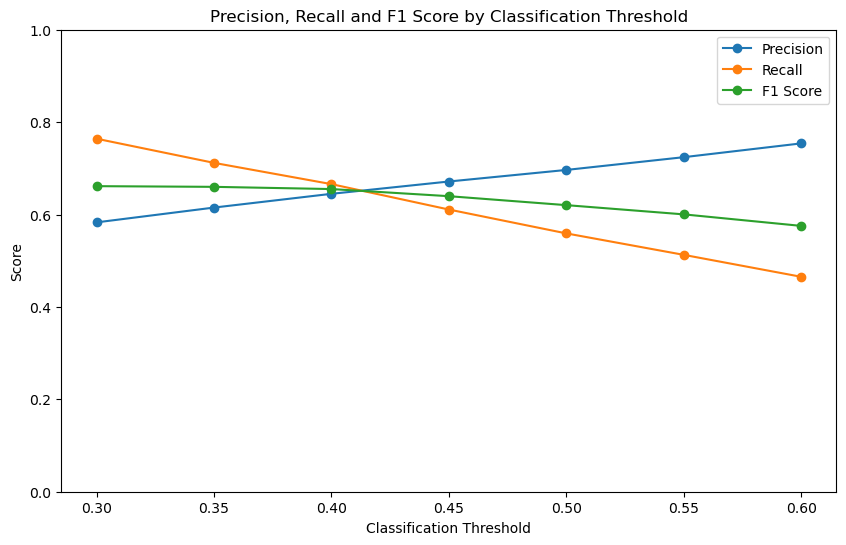

In [84]:
threshold_plot = threshold_df.set_index("Threshold")

plt.figure(figsize=(10, 6))
plt.plot(threshold_plot.index, threshold_plot["Precision"], marker="o", label="Precision")
plt.plot(threshold_plot.index, threshold_plot["Recall"], marker="o", label="Recall")
plt.plot(threshold_plot.index, threshold_plot["F1 Score"], marker="o", label="F1 Score")
plt.title("Precision, Recall and F1 Score by Classification Threshold")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.show()

In [85]:
selected_threshold = 0.40

y_pred_rf_tuned = (y_prob_rf >= selected_threshold).astype(int)

print("Random Forest Performance with Tuned Threshold:", selected_threshold)
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf_tuned), 4))
print("Precision:", round(precision_score(y_test, y_pred_rf_tuned), 4))
print("Recall:", round(recall_score(y_test, y_pred_rf_tuned), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_rf_tuned), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_tuned))

Random Forest Performance with Tuned Threshold: 0.4
Accuracy: 0.8071
Precision: 0.6448
Recall: 0.6658
F1 Score: 0.6551

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.87     12643
           1       0.64      0.67      0.66      4802

    accuracy                           0.81     17445
   macro avg       0.76      0.76      0.76     17445
weighted avg       0.81      0.81      0.81     17445



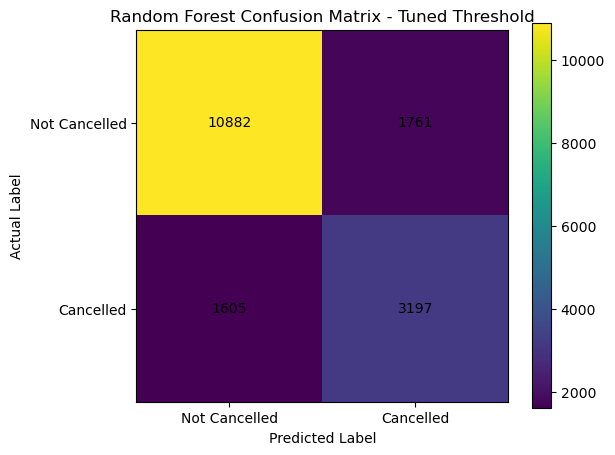

In [86]:
rf_tuned_cm = confusion_matrix(y_test, y_pred_rf_tuned)

plt.figure(figsize=(6, 5))
plt.imshow(rf_tuned_cm)
plt.title("Random Forest Confusion Matrix - Tuned Threshold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["Not Cancelled", "Cancelled"])
plt.yticks([0, 1], ["Not Cancelled", "Cancelled"])

for i in range(rf_tuned_cm.shape[0]):
    for j in range(rf_tuned_cm.shape[1]):
        plt.text(j, i, rf_tuned_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

Lowering the classification threshold increased the model's ability to identify actual cancellations. This is useful for hotel operations because it allows the model to flag more high-risk bookings for follow-up. However, this comes with a trade-off: more bookings may be incorrectly flagged as likely cancellations.

### 4. Cross-validation
Cross-validation was used to evaluate whether the Random Forest model performs consistently across different splits of the dataset.

In [87]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    random_forest_model,
    X,
    y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("Cross-validation ROC-AUC scores:", cv_scores)
print("Mean ROC-AUC:", round(cv_scores.mean(), 4))
print("Standard deviation:", round(cv_scores.std(), 4))

Cross-validation ROC-AUC scores: [0.73539021 0.6854116  0.54785749 0.51109977 0.66781223]
Mean ROC-AUC: 0.6295
Standard deviation: 0.0854


### 5. Hyperparameter tuning
Hyperparameter tuning was performed to test different Random Forest settings and improve model performance.

In [88]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

rf_random_search = RandomizedSearchCV(
    estimator=random_forest_model,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(X_train, y_train)

print("Best Parameters:")
print(rf_random_search.best_params_)

print("Best Cross-Validated ROC-AUC:")
print(round(rf_random_search.best_score_, 4))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:
{'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': 30}
Best Cross-Validated ROC-AUC:
0.8553


In [89]:
#Tuned model
best_rf_model = rf_random_search.best_estimator_

y_pred_best_rf = best_rf_model.predict(X_test)
y_prob_best_rf = best_rf_model.predict_proba(X_test)[:, 1]

print("Tuned Random Forest Performance")
print("--------------------------------")
print("Accuracy:", round(accuracy_score(y_test, y_pred_best_rf), 4))
print("Precision:", round(precision_score(y_test, y_pred_best_rf), 4))
print("Recall:", round(recall_score(y_test, y_pred_best_rf), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_best_rf), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_best_rf), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_rf))

Tuned Random Forest Performance
--------------------------------
Accuracy: 0.8112
Precision: 0.642
Recall: 0.7105
F1 Score: 0.6745
ROC-AUC: 0.8659

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87     12643
           1       0.64      0.71      0.67      4802

    accuracy                           0.81     17445
   macro avg       0.76      0.78      0.77     17445
weighted avg       0.82      0.81      0.81     17445



## Gradient Boosting Model
Gradient Boosting was tested as an additional tree-based model. It builds trees sequentially, where each new tree tries to correct the mistakes of the previous trees. This can often improve performance on structured/tabular datasets.

In [91]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ]
)

gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully")

Gradient Boosting model trained successfully


In [92]:
y_pred_gb = gradient_boosting_model.predict(X_test)
y_prob_gb = gradient_boosting_model.predict_proba(X_test)[:, 1]

gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb)
gb_recall = recall_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)
gb_roc_auc = roc_auc_score(y_test, y_prob_gb)

print("Gradient Boosting Performance")
print("-----------------------------")
print("Accuracy:", round(gb_accuracy, 4))
print("Precision:", round(gb_precision, 4))
print("Recall:", round(gb_recall, 4))
print("F1 Score:", round(gb_f1, 4))
print("ROC-AUC:", round(gb_roc_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Performance
-----------------------------
Accuracy: 0.8085
Precision: 0.7248
Recall: 0.4904
F1 Score: 0.585
ROC-AUC: 0.8475

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88     12643
           1       0.72      0.49      0.59      4802

    accuracy                           0.81     17445
   macro avg       0.78      0.71      0.73     17445
weighted avg       0.80      0.81      0.80     17445



## XGBoost Model

In [94]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 330.3 kB/s eta 0:05:08
   ---------------------------------------- 0.1/101.7 MB 919.0 kB/s eta 0:01:51
   ---------------------------------------- 0.2/101.7 MB 1.9 MB/s eta 0:00:54
   ---------------------------------------- 0.6/101.7 MB 3.3 MB/s eta 0:00:31
   ---------------------------------------- 0.8/101.7 MB 3.8 MB/s eta 0:00:27
   ---------------------------------------- 1.2/101.7 MB 4.3 MB/s eta 0:00:24
    --------------------------------------- 1.4/101.7 MB 4.8 MB/s eta 0:00:21
    --------------------------------------- 1.8/101.7 MB 4.9 MB/s eta 0:00:21
    --------------------------------------- 2.0/101.7 MB 5.1 MB/s eta 0:00:20
    --------------------------------------- 2.5/101.7 MB 5.5 MB/s eta 0:00:19
   - -------------------------------------- 2.7/101.7 MB 5.6 MB/s eta 0:00:18
   - -------------------------------------- 3.0/101.7 MB 5.7 MB/s e

In [97]:
from xgboost import XGBClassifier
print("XGBoost imported successfully")

XGBoost imported successfully


XGBoost was tested as an advanced boosting model. It is commonly used for structured machine learning problems because it can capture complex relationships and often performs well on tabular datasets.

In [98]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully")

XGBoost model trained successfully


In [99]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Performance")
print("-------------------")
print("Accuracy:", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall:", round(xgb_recall, 4))
print("F1 Score:", round(xgb_f1, 4))
print("ROC-AUC:", round(xgb_roc_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Performance
-------------------
Accuracy: 0.8208
Precision: 0.7496
Recall: 0.5237
F1 Score: 0.6166
ROC-AUC: 0.8605

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88     12643
           1       0.75      0.52      0.62      4802

    accuracy                           0.82     17445
   macro avg       0.79      0.73      0.75     17445
weighted avg       0.81      0.82      0.81     17445



In [100]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        gb_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision,
        gb_precision,
        xgb_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall,
        gb_recall,
        xgb_recall
    ],
    "F1 Score": [
        logistic_f1,
        rf_f1,
        gb_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        rf_roc_auc,
        gb_roc_auc,
        xgb_roc_auc
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.801032,0.694534,0.494794,0.577891,0.826288
1,Random Forest,0.812324,0.702116,0.552686,0.618504,0.850887
2,Gradient Boosting,0.808484,0.724838,0.490421,0.585020,0.847541
3,XGBoost,0.820751,0.749627,0.523740,0.616648,0.860544


### Updated Model Comparison Chart

<Figure size 1200x600 with 0 Axes>

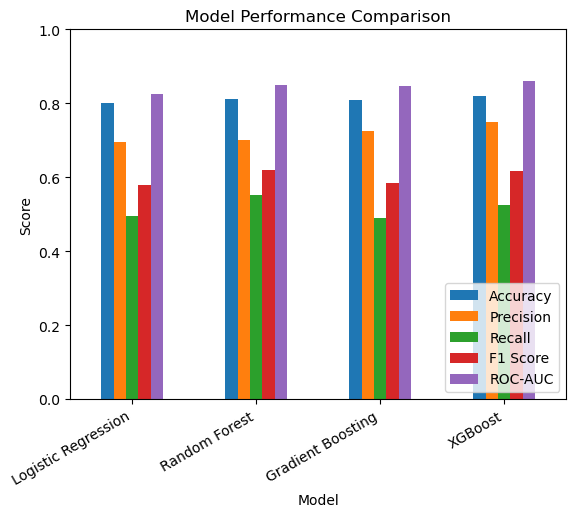

In [101]:
model_comparison_plot = model_comparison.set_index("Model")

plt.figure(figsize=(12, 6))

model_comparison_plot[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(kind="bar")

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.show()

### XGBoost Confusion Matrix

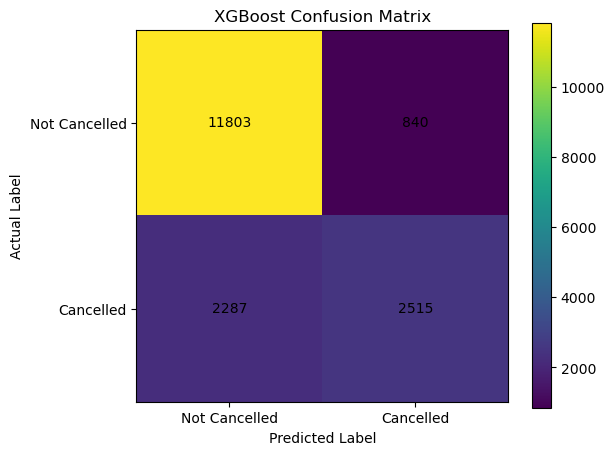

In [102]:
xgb_cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
plt.imshow(xgb_cm)
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["Not Cancelled", "Cancelled"])
plt.yticks([0, 1], ["Not Cancelled", "Cancelled"])

for i in range(xgb_cm.shape[0]):
    for j in range(xgb_cm.shape[1]):
        plt.text(j, i, xgb_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

### 6. Saving the model

In [90]:
import joblib

joblib.dump(best_rf_model, "hotel_cancellation_random_forest_model.pkl")

print("Model saved successfully")

Model saved successfully


In [105]:
hotel_df.to_csv("hotel_bookings_cleaned_enhanced.csv", index=False)

The trained Random Forest model was saved as a `.pkl` file so it could be reused later for prediction or deployment.

## Final Model Selection

XGBoost was selected as the final model because it achieved the best overall performance across the tested models. It had the highest accuracy, precision, F1-score, and ROC-AUC.

Random Forest had slightly better recall, meaning it caught more actual cancellations, but XGBoost produced fewer false positives and better overall separation between cancelled and non-cancelled bookings. For this project, XGBoost was selected as the strongest overall model, while threshold tuning could be used later if the business wants to prioritise recall.

# Final Business Conclusion

This project analysed hotel booking cancellations using data cleaning, exploratory data analysis, advanced feature engineering, and machine learning. The goal was to identify the key factors associated with cancellations and build a model that could help predict cancellation risk.

The exploratory analysis showed that cancellation behaviour was strongly influenced by lead time, ADR, customer type, market segment, deposit type, stay length, special requests, booking changes, previous booking history, and room assignment status. Longer lead times, higher ADR price bands, transient customers, and online travel agency bookings were associated with higher cancellation risk, while returning guests, bookings with special requests, and bookings with changes showed lower cancellation rates.

Four machine learning models were tested: Logistic Regression, Random Forest, Gradient Boosting, and XGBoost. XGBoost achieved the best overall performance, with the highest accuracy, precision, F1-score, and ROC-AUC among the tested models.

The XGBoost model achieved:
- Accuracy: 82.08%
- Precision: 74.96%
- Recall: 52.37%
- F1-score: 61.66%
- ROC-AUC: 86.05%

Although Random Forest achieved slightly higher recall, XGBoost delivered the strongest overall performance because it produced the highest ROC-AUC, highest precision, and highest accuracy. This means XGBoost was better at separating cancelled and non-cancelled bookings overall, while also producing fewer false cancellation alerts compared to the other models.

The XGBoost confusion matrix showed that the model correctly predicted 11,803 non-cancelled bookings and 2,515 cancelled bookings. It incorrectly flagged 840 non-cancelled bookings as cancelled and missed 2,287 actual cancellations. This suggests that the model is useful as a cancellation risk-screening tool, but further recall improvement would be valuable if the business goal is to catch more potential cancellations.

From a business perspective, this model could help hotel front office and revenue teams identify high-risk bookings earlier. This could support better occupancy forecasting, targeted guest follow-ups, improved cancellation policy planning, and more informed operational decision-making.

The model should not replace human judgement, but it can be used as a decision-support tool to prioritise bookings that may need additional attention. For example, bookings with long lead times, high ADR, no special requests, previous cancellation history, or high-risk booking channels could be flagged for proactive confirmation or follow-up.

Overall, the project demonstrates how data analytics and machine learning can support hospitality operations by turning historical booking data into actionable cancellation risk insights.